# NEST Simulation from SONATA

This notebook demonstrates how to:
1. Generate a SONATA simulation config for the **core_nll_7** circuit
2. Run the simulation using the NEST simulator via `NestSimulationFromSonataTask`
3. Load and plot the results

**Prerequisites:** `pip install nest-simulator`

In [1]:
import json
from pathlib import Path

CIRCUIT_BASE = Path("/Users/james/Documents/obi/code/obi-main/core_nll_7")
OUTPUT_ROOT = Path("../../../obi-output/nest_core_nll_7")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NETWORK_DIR = CIRCUIT_BASE / "network"
COMPONENTS_DIR = CIRCUIT_BASE / "components"
LGN_SPIKE_FILE = str(CIRCUIT_BASE / "filternet" / "spikes.h5")
BKG_SPIKE_FILE = str(CIRCUIT_BASE / "bkg" / "bkg_spikes_250Hz_3s.h5")

## 1. Generate the SONATA simulation config

We build a `simulation_config.json` and `circuit_config.json` for the core_nll_7
V1 cortical circuit (66,952 point neurons, ~56M synapses). The circuit uses
NEST `glif_psc_double_alpha` models natively.

In [2]:
circuit_config = {
    "version": 2.3,
    "manifest": {"$BASE_DIR": "./"},
    "components": {
        "point_neuron_models_dir": str(COMPONENTS_DIR / "cell_models"),
        "synaptic_models_dir": str(COMPONENTS_DIR / "synaptic_models"),
    },
    "networks": {
        "nodes": [
            {
                "nodes_file": str(NETWORK_DIR / "v1_nodes.h5"),
                "node_types_file": str(NETWORK_DIR / "v1_node_types.csv"),
                "populations": {"v1": {"type": "point_process"}},
            },
            {
                "nodes_file": str(NETWORK_DIR / "lgn_nodes.h5"),
                "node_types_file": str(NETWORK_DIR / "lgn_node_types.csv"),
                "populations": {"lgn": {"type": "virtual"}},
            },
            {
                "nodes_file": str(NETWORK_DIR / "bkg_nodes.h5"),
                "node_types_file": str(NETWORK_DIR / "bkg_node_types.csv"),
                "populations": {"bkg": {"type": "virtual"}},
            },
        ],
        "edges": [
            {
                "edges_file": str(NETWORK_DIR / "v1_v1_edges_bio_trained.h5"),
                "edge_types_file": str(NETWORK_DIR / "v1_v1_edge_types.csv"),
                "populations": {"v1_to_v1": {"type": "chemical"}},
            },
            {
                "edges_file": str(NETWORK_DIR / "lgn_v1_edges.h5"),
                "edge_types_file": str(NETWORK_DIR / "lgn_v1_edge_types.csv"),
                "populations": {"lgn_to_v1": {"type": "chemical"}},
            },
            {
                "edges_file": str(NETWORK_DIR / "bkg_v1_edges_bio_trained.h5"),
                "edge_types_file": str(NETWORK_DIR / "bkg_v1_edge_types.csv"),
                "populations": {"bkg_to_v1": {"type": "chemical"}},
            },
        ],
    },
}

circuit_config_path = OUTPUT_ROOT / "circuit_config.json"
with circuit_config_path.open("w", encoding="utf-8") as f:
    json.dump(circuit_config, f, indent=2)

print(f"Circuit config written to {circuit_config_path}")

Circuit config written to ../../../obi-output/nest_core_nll_7/circuit_config.json


In [ ]:
SIM_LENGTH_MS = 500.0

simulation_config = {
    "version": 2.4,
    "target_simulator": "NEST",
    "run": {
        "dt": 0.1,
        "tstop": SIM_LENGTH_MS,
        "random_seed": 42,
    },
    "conditions": {
        "v_init": -70.0,
    },
    "output": {
        "output_dir": "nest_output",
        "spikes_file": "spikes.h5",
    },
    "network": "circuit_config.json",
    "node_sets_file": "",
    "inputs": {
        "LGN_spikes": {
            "module": "synapse_replay",
            "input_type": "spikes",
            "spike_file": LGN_SPIKE_FILE,
            "node_set": "lgn",
        },
        "BKG_spikes": {
            "module": "synapse_replay",
            "input_type": "spikes",
            "spike_file": BKG_SPIKE_FILE,
            "node_set": "bkg",
        },
        "ConstantCurrent": {
            "module": "linear",
            "input_type": "current_clamp",
            "node_set": "v1",
            "amp_start": 0.3,
            "delay": 10.0,
            "duration": 300.0,
        },
    },
    "reports": {
        "soma_voltage": {
            "type": "compartment",
            "variable_name": "v",
            "cells": "v1",
            "dt": 1.0,
            "start_time": 0.0,
            "end_time": SIM_LENGTH_MS,
        },
    },
}

sim_config_path = OUTPUT_ROOT / "simulation_config.json"
with sim_config_path.open("w", encoding="utf-8") as f:
    json.dump(simulation_config, f, indent=2)

print(f"Simulation config written to {sim_config_path}")
print(f"  Duration: {SIM_LENGTH_MS} ms")
print(f"  Inputs: LGN spikes, BKG spikes, constant current (0.05 nA, 10-40 ms)")
print(f"  Reports: soma voltage recording")

Simulation config written to ../../../obi-output/nest_core_nll_7/simulation_config.json
  Duration: 500.0 ms
  Inputs: LGN spikes, BKG spikes, constant current (0.05 nA, 10-40 ms)
  Reports: soma voltage recording


## 2. Run the NEST simulation

Create the `NestSimulationFromSonataSingleConfig` and execute the task.
This builds the NEST network from the SONATA HDF5 files, applies stimuli
and recordings via the mirrored handler classes, and simulates.

In [4]:
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

In [5]:
from obi_one.core.path import NamedPath
from obi_one.scientific.tasks.nest_simulation_from_sonata.config import (
    NestSimulationFromSonataSingleConfig,
)
from obi_one.scientific.tasks.nest_simulation_from_sonata.task import (
    NestSimulationFromSonataTask,
)

nest_config = NestSimulationFromSonataSingleConfig.empty_config()

initialize = NestSimulationFromSonataSingleConfig.Initialize(
    simulation_config_path=NamedPath(
        name="core_nll_7 simulation",
        path=str(sim_config_path.resolve()),
    ),
    # The core_nll_7 circuit already uses NEST point neuron models
    # (glif_psc_double_alpha), so the nest_model parameter is only
    # used as a fallback for biophysical populations.
    nest_model="iaf_psc_alpha",
)
nest_config.set(initialize, name="initialize")

# Set output root for the task
nest_config.scan_output_root = str(OUTPUT_ROOT)
nest_config.coordinate_output_root = str(OUTPUT_ROOT)

INFO numexpr.utils: NumExpr defaulting to 14 threads.


In [6]:
task = NestSimulationFromSonataTask(config=nest_config)
task.execute()

INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Created 66952 NEST neurons for population 'v1' (type=point_process, model=iaf_psc_alpha)



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Oct  2 2025 07:09:22

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


Apr 01 00:51:52 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.


INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Created 17400 NEST neurons for population 'lgn' (type=virtual, model=spike_generator)
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Created 100 NEST neurons for population 'bkg' (type=virtual, model=spike_generator)
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Connected 24653124 edges: v1 -> v1
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Connected 31878324 edges: lgn -> v1
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Connected 267808 edges: bkg -> v1
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Input 'LGN_spikes' targets virtual population 'lgn'; spikes already loaded during network build.
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Input 'BKG_spikes' targets virtual population 'bkg'; spikes already loaded during network build.
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Applied input 'Cons


Apr 01 00:52:10 NodeManager::prepare_nodes [Info]: 
    Preparing 84455 nodes for simulation.

Apr 01 00:52:11 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 84455
    Simulation time (ms): 500
    Number of OpenMP threads: 1
    Not using MPI

Apr 01 00:52:24 SimulationManager::run [Info]: 
    Simulation finished.


INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Spike output written to ../../../obi-output/nest_core_nll_7/nest_output/spikes.h5
INFO obi_one.scientific.tasks.nest_simulation_from_sonata.task: Voltage output written to ../../../obi-output/nest_core_nll_7/nest_output/voltage.h5


## 3. Analyze results

Load the SONATA-format output files and plot spike rasters and voltage traces.

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

spike_file = OUTPUT_ROOT / "nest_output" / "spikes.h5"
voltage_file = OUTPUT_ROOT / "nest_output" / "voltage.h5"

Population 'v1': 277 spikes from 110 neurons


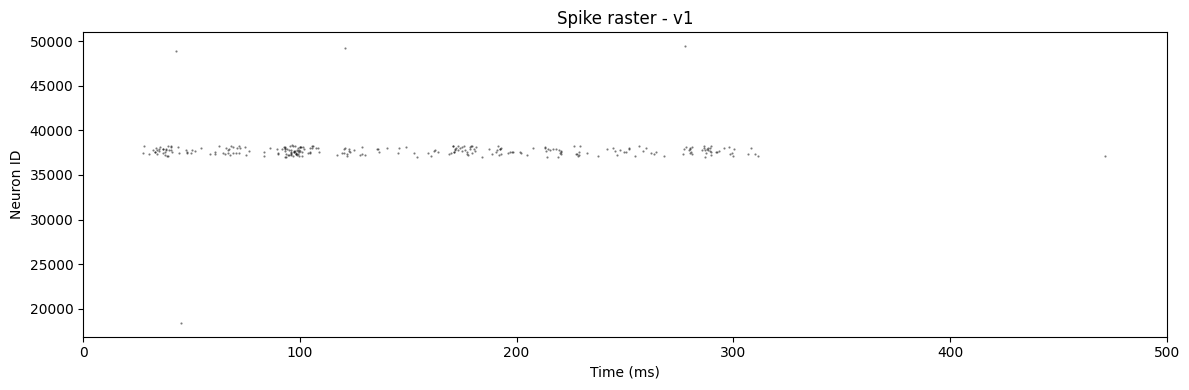

In [8]:
with h5py.File(spike_file, "r") as f:
    for pop_name in f["spikes"]:
        timestamps = f["spikes"][pop_name]["timestamps"][:]
        node_ids = f["spikes"][pop_name]["node_ids"][:]
        print(f"Population '{pop_name}': {len(timestamps)} spikes from {len(np.unique(node_ids))} neurons")

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.scatter(timestamps, node_ids, s=0.3, alpha=0.5, c="black")
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Neuron ID")
        ax.set_title(f"Spike raster - {pop_name}")
        ax.set_xlim(0, SIM_LENGTH_MS)
        plt.tight_layout()
        plt.show()

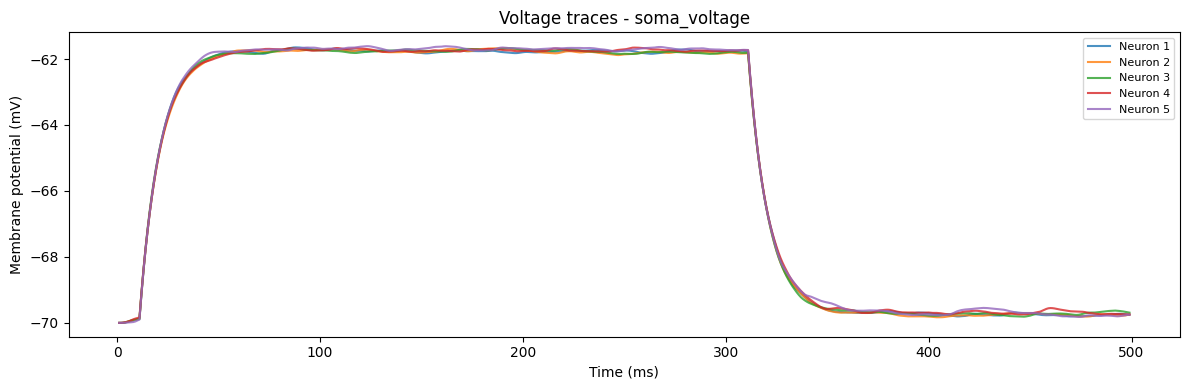

In [9]:
if voltage_file.exists():
    with h5py.File(voltage_file, "r") as f:
        for report_name in f["reports"]:
            grp = f["reports"][report_name]
            senders = grp["senders"][:]
            timestamps = grp["timestamps"][:]
            data = grp["data"][:]

            unique_neurons = np.unique(senders)[:5]  # plot first 5 neurons
            fig, ax = plt.subplots(figsize=(12, 4))
            for nid in unique_neurons:
                mask = senders == nid
                ax.plot(timestamps[mask], data[mask], label=f"Neuron {nid}", alpha=0.8)
            ax.set_xlabel("Time (ms)")
            ax.set_ylabel("Membrane potential (mV)")
            ax.set_title(f"Voltage traces - {report_name}")
            ax.legend(loc="upper right", fontsize=8)
            plt.tight_layout()
            plt.show()
else:
    print("No voltage output file found.")